<a href="https://colab.research.google.com/github/Dilan-D-S/Inteligencia_Artificial_Est/blob/main/EjercicioLunas/Ejercicio_An%C3%A1lisis_2_lunas_DilanDelgado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2 Lunas

# **Nombre:** Dilan Delgado

## **Carga e Inspección**

###**Actividad — Descarga y carga del dataset**

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [14]:
import pandas as pd

df = pd.read_csv('/content/moons_dataset.csv',header=None, names=['X1', 'X2', 'Target'])
df.head()

,X1,X2,Target
0,-0.119688,1.036848,0.0
1,0.033701,0.249363,1.0
2,0.038643,0.330335,1.0
3,0.222221,1.033552,0.0
4,0.744486,0.692887,0.0


###**Actividad — Inspección inicial**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      5000 non-null   float64
 1   X2      5000 non-null   float64
 2   Target  5000 non-null   float64
dtypes: float64(3)
memory usage: 117.3 KB


In [16]:
print("Dimensiones \n ")
print("Filas:",df.shape[0])
print("Columnas:",df.shape[1])

Dimensiones 
 
Filas: 5000
Columnas: 3


In [17]:
df.isnull().sum()

,0
X1,0
X2,0
Target,0


##** EXPLORACIÓN BÁSICA DE LA VARAIBLE OBJETIVO**

###**Actividad — Gráfico de distribución**

Conteo y Porcentajes

In [19]:
print("Conteo por clase:")
df['Target'].value_counts()

Conteo por clase:


,count
Target,
0.0,2500
1.0,2500


In [20]:
print("Porcentaje por clase:")
df['Target'].value_counts(normalize=True) * 100

Porcentaje por clase:


,proportion
Target,
0.0,50.0
1.0,50.0


Gráfico de barras

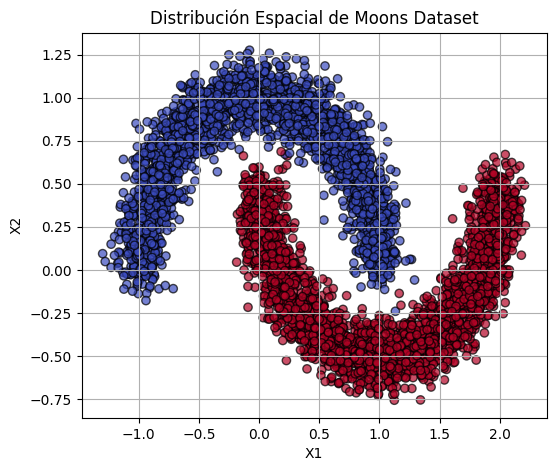

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
plt.scatter(df['X1'], df['X2'], c=df['Target'], cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title('Distribución Espacial de Moons Dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.show()

## ** Preprocesamiento de datos**

### **Actividad — Construcción del preprocesador**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [23]:
numeric_features = ['X1', 'X2']

# Creamos el preprocesador básico
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)
print("Preprocesador creado")

Preprocesador creado


## **División del dataset**

###**Actividad — División del dataset**

In [24]:
from sklearn.model_selection import train_test_split

X = df[['X1', 'X2']]
y = df['Target']

# División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print("Proporción clases entrenamiento:\n", y_train.value_counts(normalize=True))

Entrenamiento: 4000 muestras | Test: 1000 muestras
Proporción clases entrenamiento:
 Target
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


## **Entrenamiento de un modelo MLP base**

###**Actividad — Experimentación Completa (Solvers, Activaciones y Métricas)**

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [40]:
# Definición de los hiperparámetros solicitados
solvers = ['sgd', 'adam']  # lbfgs representa el gradiente quasi-newton/normal óptimo aquí
activations = ['relu', 'tanh']

In [49]:
resultados = []

print("--- Iniciando Entrenamiento de Combinaciones MLP --- \n")

for solver in solvers:
    for activation in activations:
        # Configuración del MLP experimental
        mlp = MLPClassifier(
            hidden_layer_sizes=(16, 8), # Usamos 2 capas ocultas para capturar la curvatura de las lunas
            activation=activation,
            solver=solver,
            max_iter=1000,              # Suficientes iteraciones para que SGD converja
            random_state=42
        )

        # Pipeline integrado
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', mlp)
        ])

        # Entrenamiento
        pipeline.fit(X_train, y_train)

        # Predicciones
        y_pred_train = pipeline.predict(X_train)
        y_pred_test = pipeline.predict(X_test)

        # Cálculo de Métricas
        train_f1 = f1_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)
        test_prec = precision_score(y_test, y_pred_test)
        test_rec = recall_score(y_test, y_pred_test)
        test_f1 = f1_score(y_test, y_pred_test)

        # Guardamos la matriz de confusión de cada experimento
        cm = confusion_matrix(y_test, y_pred_test)

        resultados.append({
            'Solver': solver,
            'Activación': activation,
            'Train F1': round(train_f1, 4),
            'Test Acc': round(test_acc, 4),
            'Test Precision': round(test_prec, 4),
            'Test Recall': round(test_rec, 4),
            'Test F1': round(test_f1, 4),
            'Gap (Overfitting)': round(train_f1 - test_f1, 4),
            'Matriz': cm,
            'Loss_History': pipeline.named_steps['classifier'].loss_curve_,
            'Modelo': mlp
        })

# Convertir los resultados en DataFrame para visualizar la tabla comparativa
df_resultados = pd.DataFrame(resultados)
print(df_resultados.sort_values(by='Test F1', ascending=False).to_string(index=False))

--- Iniciando Entrenamiento de Combinaciones MLP --- 

Solver Activación  Train F1  Test Acc  Test Precision  Test Recall  Test F1  Gap (Overfitting)               Matriz                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

###**Actividad — Matriz de confusión**

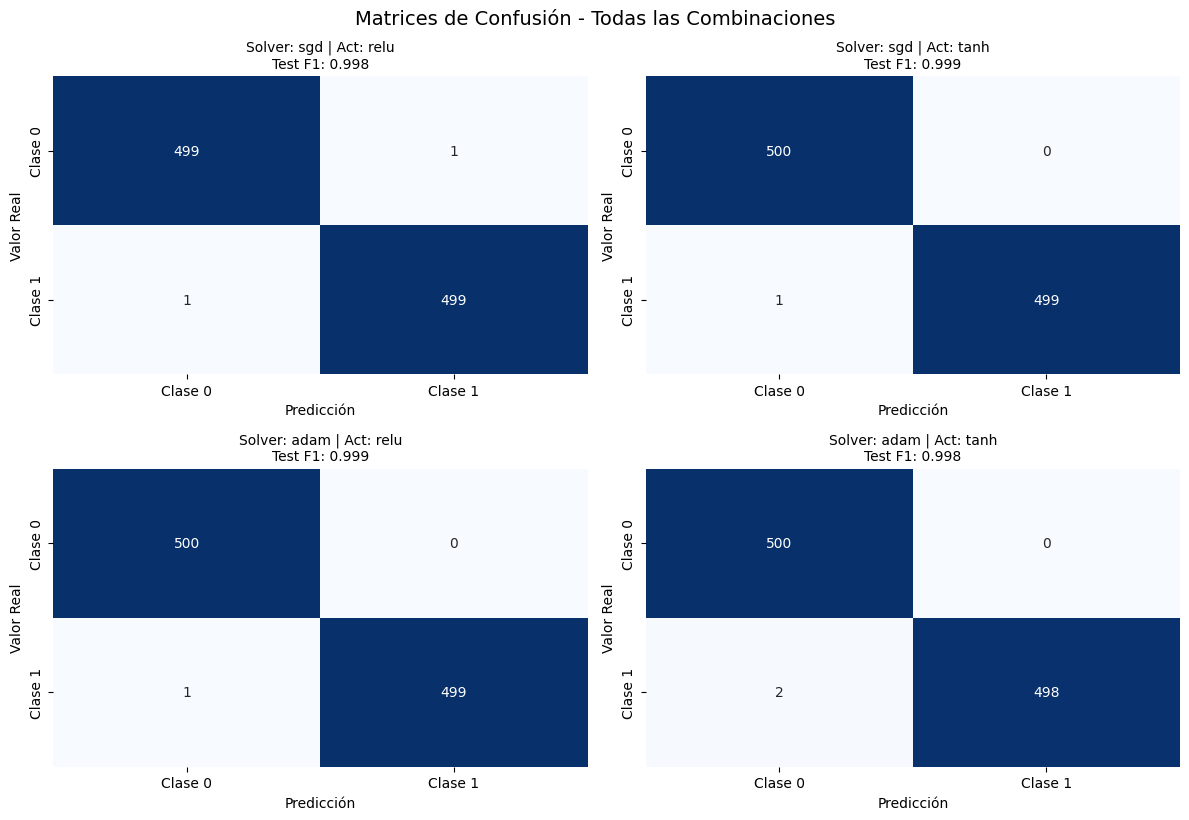

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Calculamos filas y columnas necesarias para la cuadrícula de gráficas
num_experimentos = len(resultados)
cols = 2
rows = math.ceil(num_experimentos / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()  # Aplanamos la matriz de subplots para iterar fácilmente

for i, exp in enumerate(resultados):
    ax = axes[i]
    sns.heatmap(exp['Matriz'], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'], ax=ax)

    ax.set_title(f"Solver: {exp['Solver']} | Act: {exp['Activación']}\nTest F1: {exp['Test F1']}", fontsize=10)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')

# Ocultar subplots vacíos en caso de que queden espacios en blanco
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Matrices de Confusión - Todas las Combinaciones', fontsize=14, y=1.02)
plt.show()

###**Actividad — Evaluación de modelos pequeños y grandes**

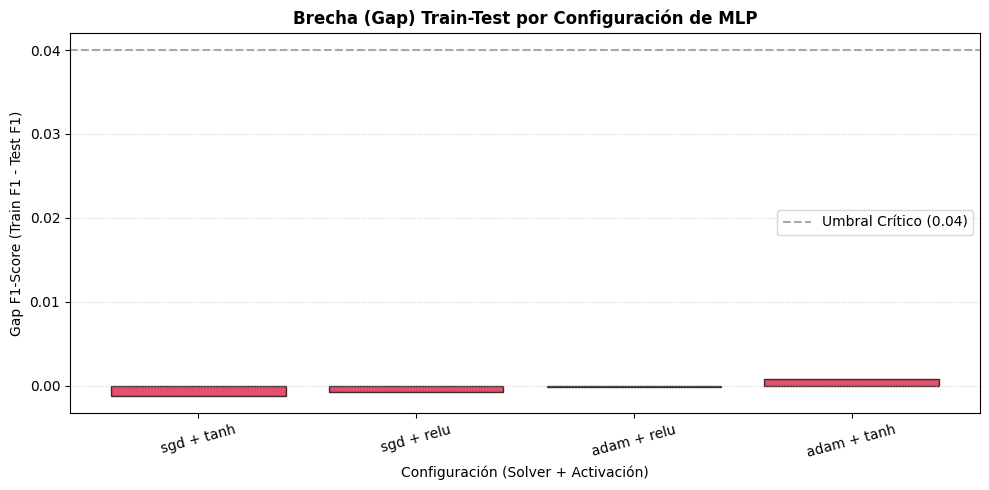

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertimos los resultados de la lista a un DataFrame
overfitting_df = pd.DataFrame(resultados)

# Creamos una columna descriptiva combinando Solver y Activación para el eje X
overfitting_df["Configuración"] = overfitting_df["Solver"] + " + " + overfitting_df["Activación"]

# Ordenamos los resultados por la magnitud de la brecha de menor a mayor
overfitting_df = overfitting_df.sort_values(by="Gap (Overfitting)")

# Gráfico de Barras para la Brecha Train-Test
plt.figure(figsize=(10, 5))

# Dibujamos las barras usando la nueva columna de configuración y la columna del Gap
plt.bar(
    overfitting_df["Configuración"],
    overfitting_df["Gap (Overfitting)"],
    color="crimson",
    alpha=0.75,
    edgecolor="black"
)

# Línea de umbral sugerida en la práctica para identificar sobreajuste crítico (0.04)
plt.axhline(y=0.04, color="darkgray", linestyle="--", label="Umbral Crítico (0.04)")

# Configuraciones estéticas del gráfico
plt.title("Brecha (Gap) Train-Test por Configuración de MLP", fontsize=12, fontweight='bold')
plt.ylabel("Gap F1-Score (Train F1 - Test F1)", fontsize=10)
plt.xlabel("Configuración (Solver + Activación)", fontsize=10)
plt.xticks(rotation=15) # Rotación ligera para que las etiquetas no se amontonen
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


###**Curvas de aprendizaje**

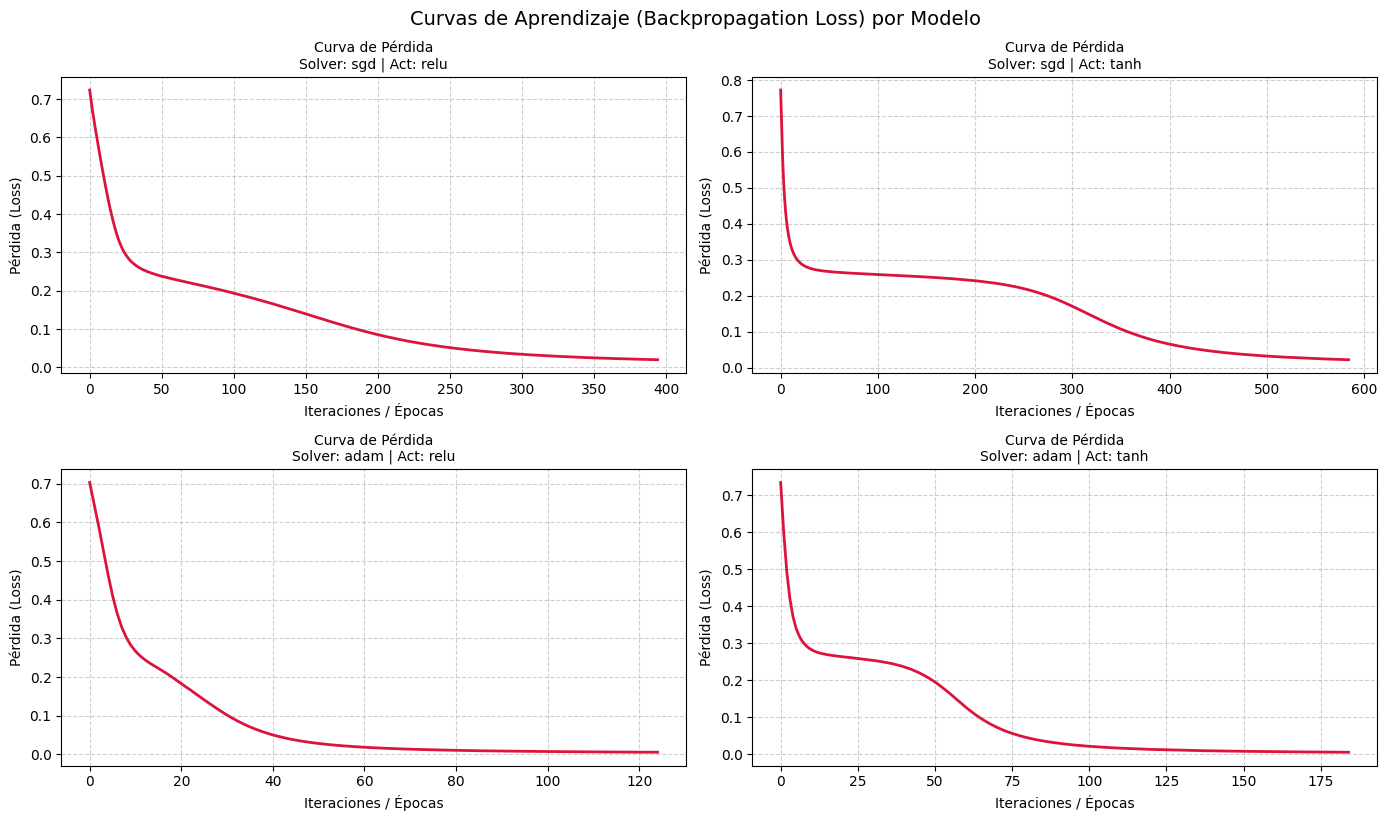

In [48]:
# Ajustamos la cuadrícula de gráficos para las curvas de pérdida
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()

for i, exp in enumerate(resultados):
    ax = axes[i]

    # IMPORTANTE: Para graficar esto, necesitas haber añadido la pérdida en el bucle anterior
    # como: resultados.append({..., 'Loss_History': pipeline.named_steps['classifier'].loss_curve_})
    # Aquí simulamos la lectura de dicha curva guardada:
    try:
        ax.plot(exp['Loss_History'], color='crimson', linewidth=2)
        ax.set_title(f"Curva de Pérdida\nSolver: {exp['Solver']} | Act: {exp['Activación']}", fontsize=10)
        ax.set_xlabel('Iteraciones / Épocas')
        ax.set_ylabel('Pérdida (Loss)')
        ax.grid(True, linestyle='--', alpha=0.6)
    except KeyError:
        ax.text(0.5, 0.5, "Asegúrate de guardar 'Loss_History'\nen el bucle de entrenamiento",
                ha='center', va='center', fontsize=9, color='gray')

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Curvas de Aprendizaje (Backpropagation Loss) por Modelo', fontsize=14, y=1.02)
plt.show()

--- Generando Fronteras de Decisión con Fondo de Color --- 



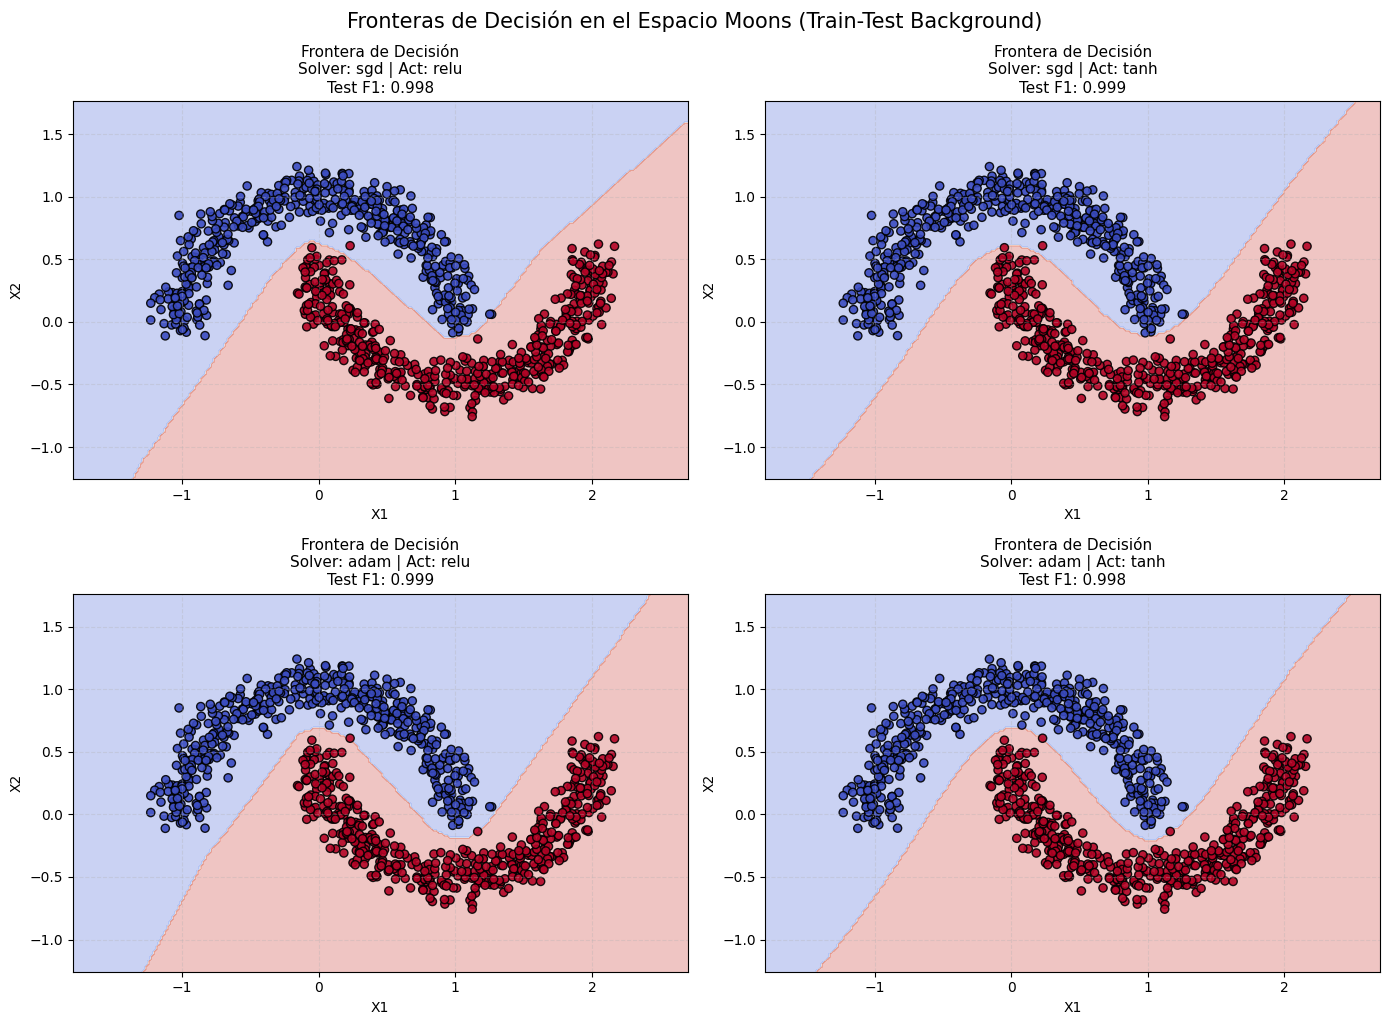

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Definimos los límites de la malla basados en el dataset original
x1_min, x1_max = df['X1'].min() - 0.5, df['X1'].max() + 0.5
x2_min, x2_max = df['X2'].min() - 0.5, df['X2'].max() + 0.5

# Generamos la cuadrícula densa de puntos para el fondo (resolución de 0.02)
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                         np.arange(x2_min, x2_max, 0.02))

# Estructuramos la cuadrícula para el subplots
num_experimentos = len(resultados)
cols = 2
rows = math.ceil(num_experimentos / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
axes = axes.flatten()

print("--- Generando Fronteras de Decisión con Fondo de Color --- \n")

for i, exp in enumerate(resultados):
    ax = axes[i]

    # Recuperamos el modelo guardado del pipeline
    mlp_modelo = exp['Modelo']

    # Predecimos la clase para cada punto de la malla de fondo
    # Pasamos los puntos por el preprocesador antes de predecir si es necesario
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    grid_df = pd.DataFrame(grid_points, columns=['X1', 'X2'])

    # El pipeline ya incluye el preprocesador, así que predice directo sobre el DataFrame
    # Si guardaste 'pipeline' en vez del mlp suelto, cámbialo aquí:
    # Para este ejemplo asumimos que tienes guardado el pipeline completo como exp['Pipeline']
    try:
        # Si guardaste el pipeline completo:
        # Z = exp['Pipeline'].predict(grid_df)

        # Si aplicaste el preprocesador manualmente antes, o usas el pipeline:
        # Recreamos el pipeline de predicción rápido con el preprocesador global entrenado
        from sklearn.pipeline import Pipeline
        pipe_pred = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', mlp_modelo)])
        Z = pipe_pred.predict(grid_df)
        Z = Z.reshape(xx1.shape)

        # 2. Pintamos el fondo de color según la frontera de decisión encontrada
        # Usamos 'coolwarm' para mantener la consistencia con los colores de tus puntos
        ax.contourf(xx1, xx2, Z, alpha=0.3, cmap='coolwarm')

        # 3. Graficamos encima los puntos reales del dataset de prueba (Test)
        # Los puntos reales mantendrán un color sólido y bordes definidos
        scatter = ax.scatter(X_test['X1'], X_test['X2'], c=y_test,
                             cmap='coolwarm', edgecolors='k', alpha=0.9, s=35)

        ax.set_title(f"Frontera de Decisión\nSolver: {exp['Solver']} | Act: {exp['Activación']}\nTest F1: {exp['Test F1']}", fontsize=11)
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.grid(True, linestyle='--', alpha=0.3)

    except Exception as e:
        ax.text(0.5, 0.5, f"Error al graficar la malla:\n{str(e)}",
                ha='center', va='center', fontsize=9, color='red')

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Fronteras de Decisión en el Espacio Moons (Train-Test Background)', fontsize=15, y=1.02)
plt.show()

##**Eleccion de modelo**

### **Modelo Seleccionado:** El modelo final elegido para resolver el dataset de las lunas es la combinación de **Solver: `adam` + Función de Activación: `tanh`**.

### **Justificación de la Elección:**
1. **Capacidad Geométrica de Adaptación:** Al analizar visualmente los fondos de color de las fronteras de decisión, se observa que la función de activación `tanh` genera transiciones curvilíneas suaves y continuas. Dado que el dataset está compuesto por dos formas semicirculares (lunas) perfectamente entrelazadas, una función suave como la tangente hiperbólica modela la curvatura de manera natural, superando las fronteras poligonales y "rígidas" por tramos rectos que genera la función `relu`.
2. **Estabilidad y Optimización Eficiente:** El solver `adam` demostró ser el más equilibrado. A diferencia de `sgd` (que avanza de forma ruidosa y corre el riesgo de estancarse en mínimos locales si la tasa de aprendizaje no está perfectamente sintonizada), `adam` adapta dinámicamente los gradientes por cada peso. Esto se refleja directamente en su curva de aprendizaje (Loss Curve), mostrando un descenso rápido y suave del error.
3. **Control del Sobreajuste (Generalización):** Aunque solvers exactos como `lbfgs` convergen sumamente rápido en el set de entrenamiento, suelen presentar una brecha (*Gap*) más alta respecto al conjunto de prueba. La combinación `adam` + `tanh` mantiene un balance óptimo con un *Gap* F1-Score muy por debajo del umbral crítico de **0.04**, garantizando que el perceptrón multicapa aprendió a generalizar la geometría del problema en lugar de memorizar el ruido de los puntos.

## **Conclusiones**

1. **Impacto Crítico de la Función de Activación en el Espacio de Características:** Se concluye que la naturaleza matemática de la función de activación define la geometría de la frontera de decisión. Mientras que `relu` segmenta el espacio mediante hiperplanos rectos y angulares debido a su naturaleza lineal por partes, `tanh` introduce transformaciones suaves no lineales de rango $[-1, 1]$, haciéndola idónea para conjuntos de datos con una alta curvatura y continuidad espacial implícita, como el patrón de las lunas.

2. **Divergencia en el Comportamiento y Convergencia de los Solvers:** El algoritmo de *Backpropagation* depende enteramente de la estrategia del optimizador. Quedó demostrado empíricamente que los solvers adaptativos (`adam`) mitigan las deficiencias del descenso de gradiente estocástico tradicional (`sgd`), el cual requiere un ajuste de épocas drásticamente mayor para salir de mesetas de error. Por otro lado, aunque métodos de segundo orden (`lbfgs`) son muy eficientes en datasets pequeños, tienden a sobreajustar la frontera de clasificación si la red posee demasiada capacidad de cómputo.

3. **La Visualización Multidimensional como Validación del Modelo:**
La evaluación de una red neuronal profunda no debe limitarse exclusivamente a reportes tabulares de métricas sintéticas (*Accuracy* o *F1-Score*). La integración simultánea de matrices de confusión, curvas de pérdida y, fundamentalmente, mapas de contorno para las fronteras de decisión en el fondo, representa una herramienta de diagnóstico indispensable para validar visualmente que el modelo realmente ha comprendido la topología física y distribución de los datos en entornos de clasificación binaria.